# Tutorial 2: SPOTS (Mouse Spleen dataset)

DePass was applied to the mouse spleen SPOTS dataset (2,568 spatial spots) for cross-modal integration and data enhancement. This tutorial demonstrates: 
1. Spatial domain identification in mouse spleen tissue using DePass.
2. Validation of data enhancement through comparative analysis of biomarker log2 fold-changes (LogFC) and spatial expression patterns.

### Preparation

In [ ]:
import scanpy as sc
import torch
import os
import warnings
warnings.filterwarnings("ignore")
import sys
# sys.path.append('/home/jyx/DePass/')
from DePass.utils import *
fix_seed(2024)  
# Environment configuration
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

os.environ['R_HOME'] = '/home/jyx/anaconda3/envs/DePass/lib/R'
path = '../data/dataset_MouseSpleen'
os.mkdir(path) if not os.path.exists(path) else print(f"The directory '{path}' already exists.\n")

The directory '../data/dataset_MouseSpleen' already exists.



### Loading and preprocessing

In [2]:
adata_omics1 = sc.read_h5ad('/data/jyx/data/dataset_MouseSpleen/adata_RNA.h5ad')
adata_omics2 = sc.read_h5ad('/data/jyx/data/dataset_MouseSpleen/adata_ADT.h5ad')

gene = [
'Cd3g','Cd3d','Cd3e',  
'Cd4', 
'Cd8a',
'Cd19',
'Ighd',
'Cd163'
]

preprocess_data(adata=adata_omics1,modality='rna',gene_list=gene)
preprocess_data(adata=adata_omics2,modality='protein')
adata_omics1.obsm['input_feat'] = adata_omics1.obsm['X_norm'].copy()
adata_omics2.obsm['input_feat'] = adata_omics2.obsm['X_clr'].copy()
data = {'rna': adata_omics1, 'protein': adata_omics2}


### Training the model

In [3]:
from DePass.model import DePass
model = DePass(data, data_type='spatial',device=device)
output = model.train()

[Config]
Modalities: 2 | Data: spatial | Device: NVIDIA GeForce RTX 4090 

[Initializing]
Graph Construction : Running...
Graph Construction : Done!
Data Enhancement : Running...
Data Enhancement : Done!

[Training]
Model training starts...


100%|██████████| 200/200 [00:02<00:00, 96.71it/s] 

Model training finished!



In [4]:
adata = adata_omics1.copy()
adata.obsm['DePass'] = model.embedding
adata.obsm['alpha'] = model.alpha 
adata.obsm['x1_enh'] = model.x1_enh
adata.obsm['x2_enh'] = model.x2_enh

### Detect spatial domain 

In [5]:
from DePass.utils import *
clustering(adata=adata,n_clusters=3,key='DePass',add_key='DePass',method='mclust',use_pca=True)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


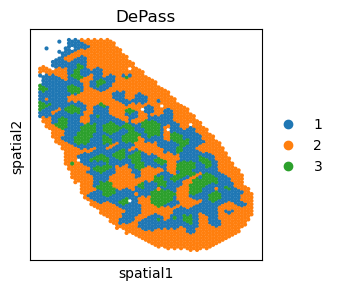

In [4]:
from DePass.utils_analysis import plot_spatial

plot_spatial(
    adata,
    color='DePass',
    save_path=path,
    save_name='DePass',
    title="DePass",
    s=35,
    show=True,
)

### Data enhancement analysis: marker LogFC and expression pattern

In [ ]:
import anndata as ad
# Create two AnnData objects to store the raw and enhanced data. 
adata1_high = adata_omics1[:,adata_omics1.var['highly_variable_all']]

adata1_R = ad.AnnData(X=adata1_high.obsm['X_norm'], obs=adata.obs[['DePass']].copy(), var=adata1_high.var.copy(), obsm={'spatial': adata1_high.obsm['spatial'].copy()})
adata1_E = ad.AnnData(X=adata.obsm['x1_enh'], obs=adata.obs[['DePass']].copy(), var=adata1_high.var.copy(), obsm={'spatial': adata1_high.obsm['spatial'].copy()})
adata2_R = ad.AnnData(X=adata_omics2.obsm['X_clr'], obs=adata.obs[['DePass']].copy(), var=adata_omics2.var.copy(), obsm={'spatial': adata_omics2.obsm['spatial'].copy()})
adata2_E = ad.AnnData(X=adata.obsm['x2_enh'], obs=adata.obs[['DePass']].copy(), var=adata_omics2.var.copy(), obsm={'spatial': adata_omics2.obsm['spatial'].copy()})

To calculate logFC values, perform differential expression analysis with scanpy.

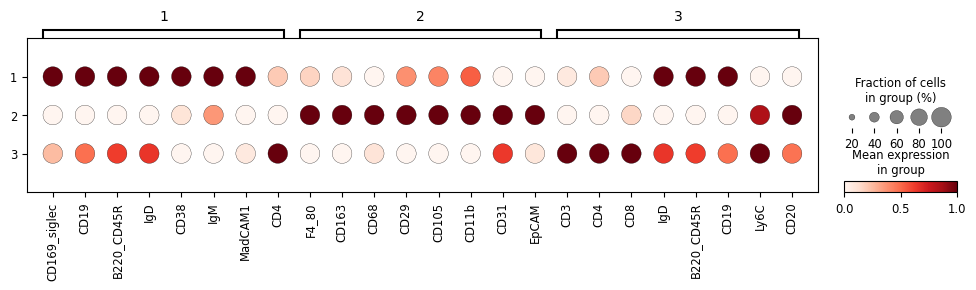

In [7]:
from DePass.utils_analysis import rank_genes_groups
rank_genes_groups(adata=adata1_R, save_path=path, groupby='DePass', figname='rank_x1_R', figsize=(12,2), n_genes=8,show=False)
rank_genes_groups(adata=adata1_E, save_path=path, groupby='DePass', figname='rank_x1_E', figsize=(12,2), n_genes=8,show=False)
rank_genes_groups(adata=adata2_R, save_path=path, groupby='DePass', figname='rank_x2_R', figsize=(12,2), n_genes=8,show=True)
rank_genes_groups(adata=adata2_E, save_path=path, groupby='DePass', figname='rank_x2_E', figsize=(12,2), n_genes=8,show=False)

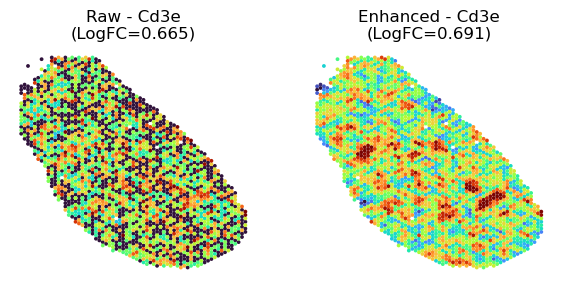

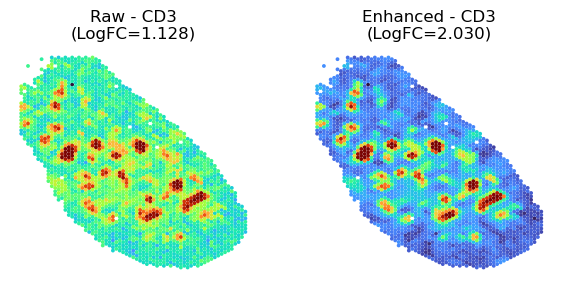

In [ ]:
from DePass.utils_analysis import plot_marker_comparison_with_logFC, truncate_expression_smartclip

adata_R_clip, adata_E_clip = truncate_expression_smartclip(adata1_R, 'Cd3e'), truncate_expression_smartclip(adata1_E, 'Cd3e')
plot_marker_comparison_with_logFC(adata_R_clip, adata_E_clip, target_gene='Cd3e', target_group='3', save_path=path, save_name='Cd3e', s=30, show=True)

adata_R_clip, adata_E_clip = truncate_expression_smartclip(adata2_R, 'CD3'), truncate_expression_smartclip(adata2_E, 'CD3')
plot_marker_comparison_with_logFC(adata_R_clip, adata_E_clip, target_gene='CD3', target_group='3', save_path=path, save_name='CD3', s=30, show=True)

In [ ]:
adata1_R.write(path+'/adata1_R.h5ad')
adata1_E.write(path+'/adata1_E.h5ad')
adata2_R.write(path+'/adata2_R.h5ad')
adata2_E.write(path+'/adata2_E.h5ad')